In [10]:
pip install rasterio geopandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import os
import glob

import rasterio
from rasterio.merge import merge
from rasterio.plot import show
from rasterio.mask import mask

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


In [12]:
data_dir = "Lab 7 data"

scene_dirs = [
    os.path.join(data_dir, d)
    for d in os.listdir(data_dir)
    if d.startswith("S2A_MSIL2A_20190821T085601")
]

shapefile = os.path.join(data_dir, "Kyiv_regions.shp")

print("Знайдено сцен:", scene_dirs)
print("Шейп-файл:", shapefile)


Знайдено сцен: ['Lab 7 data\\S2A_MSIL2A_20190821T085601_N0213_R007_T36UUA_20190821T115206.SAFE', 'Lab 7 data\\S2A_MSIL2A_20190821T085601_N0213_R007_T36UUB_20190821T115206.SAFE']
Шейп-файл: Lab 7 data\Kyiv_regions.shp


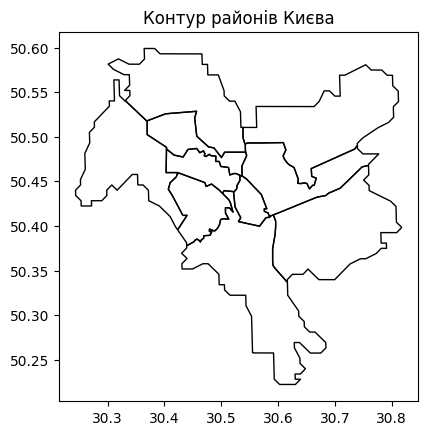

In [13]:
gdf = gpd.read_file(shapefile)
gdf = gdf.to_crs("EPSG:4326")

gdf.plot(edgecolor="black", facecolor="none")
plt.title("Контур районів Києва")
plt.show()


In [14]:
band_codes = {
    "B02": "Blue",
    "B03": "Green",
    "B04": "Red",
    "B08": "NIR"
}

merged_bands = {}

for code in band_codes:
    pattern = os.path.join(data_dir, "*", "**", f"*_{code}_10m.jp2")
    files = glob.glob(pattern, recursive=True)
    print(f"{code}: знайдено {len(files)} файлів")

    srcs = [rasterio.open(fp) for fp in files]
    mosaic, out_trans = merge(srcs)
    
    meta = srcs[0].meta.copy()
    meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": out_trans,
        "count": 1
    })
    
    merged_bands[code] = (mosaic[0], meta)
    
    for s in srcs:
        s.close()


B02: знайдено 2 файлів
B03: знайдено 2 файлів
B04: знайдено 2 файлів
B08: знайдено 2 файлів


In [15]:
stack = np.stack([
    merged_bands["B04"][0],
    merged_bands["B03"][0],
    merged_bands["B02"][0],
    merged_bands["B08"][0],
], axis=0)

out_meta = merged_bands["B04"][1]
out_meta.update({"count": 4})

merged_path = "merged_Kyiv.tif"
with rasterio.open(merged_path, "w", **out_meta) as dst:
    dst.write(stack)

print("Збережен 4-канальний растровий файл:", merged_path)


Збережен 4-канальний растровий файл: merged_Kyiv.tif


In [16]:
import rasterio
from rasterio.mask import mask

with rasterio.open(merged_path) as src:
    print("Raster CRS:", src.crs)          
    print("Vector CRS до трансформації:", gdf.crs)  

    gdf_rast = gdf.to_crs(src.crs)
    print("Vector CRS після трансформації:", gdf_rast.crs)

    shapes = [feature["geometry"] for feature in gdf_rast.__geo_interface__["features"]]

    clipped, clipped_trans = mask(src, shapes, crop=True)
    clipped_meta = src.meta.copy()
    clipped_meta.update({
        "height": clipped.shape[1],
        "width": clipped.shape[2],
        "transform": clipped_trans
    })

clipped_path = "clipped_Kyiv.tif"
with rasterio.open(clipped_path, "w", **clipped_meta) as dst:
    dst.write(clipped)

print("Збережен обрізаний файл:", clipped_path)


Raster CRS: EPSG:32636
Vector CRS до трансформації: EPSG:4326
Vector CRS після трансформації: PROJCS["WGS 84 / UTM zone 36N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",33],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32636"]]
Збережен обрізаний файл: clipped_Kyiv.tif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.8912].


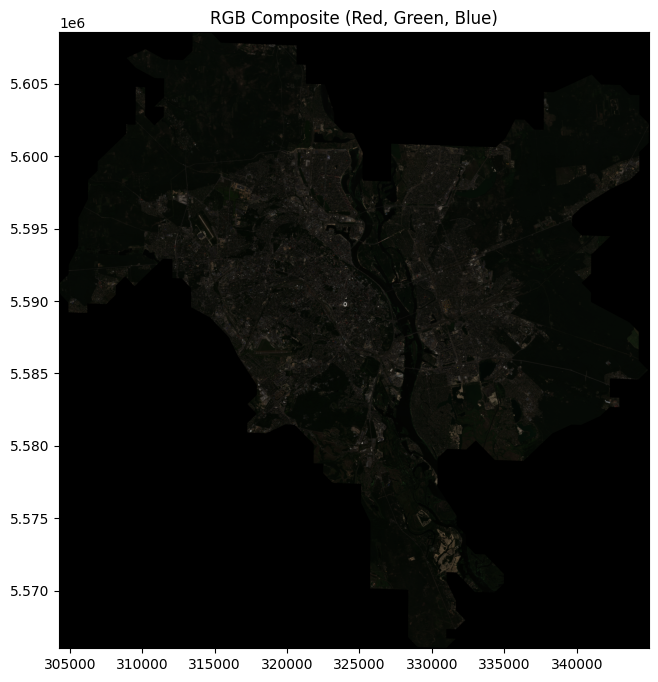

In [17]:
with rasterio.open(clipped_path) as src:
    img = src.read([1, 2, 3])  

fig, ax = plt.subplots(figsize=(8, 8))
show(img.astype(np.float32) / 10000, transform=src.transform, ax=ax)
ax.set_title("RGB Composite (Red, Green, Blue)")
plt.show()
